# Load necessary packages and helper functions

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Extract out just the window information from a dataframe. 
def windows_from_df(df, chrom_col, start_col, end_col):
    return set(zip(df[chrom_col], df[start_col], df[end_col]))

# Calculate the total overlap as a fraction. 
def overlap_fractions(left_set, right_set):
    left_only = left_set - right_set
    overlap = left_set & right_set
    right_only = right_set - left_set
    total = len(left_only) + len(overlap) + len(right_only)

    return (len(left_only) / total, len(overlap) / total, len(right_only) / total,
            (len(left_only), len(overlap), len(right_only)))

# NONO

## Setup overlap comparisons for:

In [3]:
comparisons = []

### Flipper

In [4]:
# Load in the DMSO and inactive data. 
DMSO_10R = pd.read_csv("~/scratch/ch_diffbind/testing/output/MOR_test/NONO_DMSO_R/tables/differential_windows.tsv",
                       sep="\t")
inactive_10R = pd.read_csv("~/scratch/ch_diffbind/testing/output/MOR_test/NONO_S_R/tables/differential_windows.tsv",
                           sep="\t")

# Extract out jsut the window information. 
DMSO_10R_windows = windows_from_df(DMSO_10R, "chr", "start", "end")
inactive_10R_windows = windows_from_df(inactive_10R, "chr", "start", "end")

# Add to comparisons. 
comparisons.append(("Flipper", DMSO_10R_windows, inactive_10R_windows))

### DeepRNA-reg

In [5]:
# --- Venn 1 (DeepRNA-reg) ---
DRR_DMSO_10R = pd.concat([
    pd.read_csv("~/scratch/DeepRNA-Reg/NONO_run/results/NONO_DMSO_R/enriched_cond1_NONO_DMSO_R.csv"),
    pd.read_csv("~/scratch/DeepRNA-Reg/NONO_run/results/NONO_DMSO_R/enriched_cond2_NONO_DMSO_R.csv"),
])

DRR_10S_10R = pd.concat([
    pd.read_csv("~/scratch/DeepRNA-Reg/NONO_run/results/NONO_S_R/enriched_cond1_NONO_S_R.csv"),
    pd.read_csv("~/scratch/DeepRNA-Reg/NONO_run/results/NONO_S_R/enriched_cond2_NONO_S_R.csv"),
])

comparisons.append(("DeepRNA-reg", windows_from_df(DRR_DMSO_10R, "chrom", "start", "stop"), windows_from_df(DRR_10S_10R, "chrom", "start", "stop")))


### The Adhoc method

In [6]:
# --- Venn 2 (Adhoc) ---
active_windows = pd.read_csv("/tscc/lustre/ddn/scratch/kflanagan/new_skipper_test/testing/results/NONO_skipper/output/reproducible_enriched_windows/10R.reproducible_enriched_windows.tsv.gz",
                             sep="\t")
inactive_windows = pd.read_csv("/tscc/lustre/ddn/scratch/kflanagan/new_skipper_test/testing/results/NONO_skipper/output/reproducible_enriched_windows/10S.reproducible_enriched_windows.tsv.gz",
                               sep="\t")
DMSO_windows = pd.read_csv("/tscc/lustre/ddn/scratch/kflanagan/new_skipper_test/testing/results/NONO_skipper/output/reproducible_enriched_windows/DMSO.reproducible_enriched_windows.tsv.gz",
                           sep="\t")

key_cols = ["chr", "start", "end"]

adhoc_DMSO_10R = pd.concat([
    active_windows.merge(DMSO_windows[key_cols], on=key_cols, how="left", indicator=True)
        .query('_merge == "left_only"').drop(columns="_merge"),
    DMSO_windows.merge(active_windows[key_cols], on=key_cols, how="left", indicator=True)
        .query('_merge == "left_only"').drop(columns="_merge"),
])

adhoc_10S_10R = pd.concat([
    active_windows.merge(inactive_windows[key_cols], on=key_cols, how="left", indicator=True)
        .query('_merge == "left_only"').drop(columns="_merge"),
    inactive_windows.merge(active_windows[key_cols], on=key_cols, how="left", indicator=True)
        .query('_merge == "left_only"').drop(columns="_merge"),
])

comparisons.append(("Ad-hoc", windows_from_df(adhoc_DMSO_10R, "chr", "start", "end"), windows_from_df(adhoc_10S_10R, "chr", "start", "end")))

### Diff-Skipper

In [7]:
diff_skip_DMSO_10R = pd.concat([
    pd.read_csv("~/scratch/new_skipper_test/testing/results/NONO_skipper_diff2/output/reproducible_enriched_windows/10R_DMSO.reproducible_enriched_windows.tsv.gz",
                sep="\t"
    ),
    pd.read_csv("~/scratch/new_skipper_test/testing/results/NONO_skipper_diff2/output/reproducible_enriched_windows/DMSO_10R.reproducible_enriched_windows.tsv.gz",
                sep="\t")])

diff_skip_10S_10R = pd.concat([
    pd.read_csv("~/scratch/new_skipper_test/testing/results/NONO_skipper_diff2/output/reproducible_enriched_windows/10R_10S.reproducible_enriched_windows.tsv.gz",
                sep="\t"),
    pd.read_csv("~/scratch/new_skipper_test/testing/results/NONO_skipper_diff2/output/reproducible_enriched_windows/10S_10R.reproducible_enriched_windows.tsv.gz",
                sep="\t")])

comparisons.append(("Diff-Skipper",  windows_from_df(diff_skip_DMSO_10R, "chr", "start", "end"),
                    windows_from_df(diff_skip_10S_10R, "chr", "start", "end")))

/scratch/kflanagan/job_10943595/ipykernel_2643976/3878745143.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  diff_skip_DMSO_10R = pd.concat([
/scratch/kflanagan/job_10943595/ipykernel_2643976/3878745143.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  diff_skip_10S_10R = pd.concat([


## Plotting

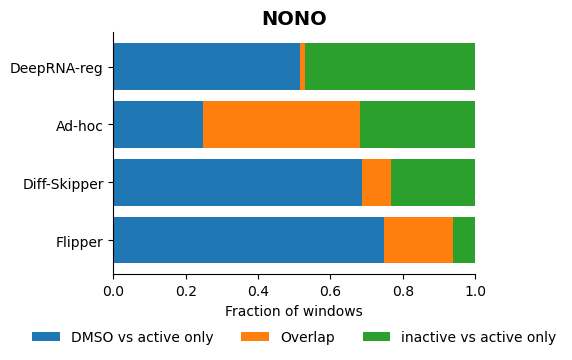

In [8]:
# Extract out the label for each comparison. 
labels = [c[0] for c in comparisons]

# Create empty vectors to store overlap fractions in. 
f_left, f_overlap, f_right = [], [], []
counts = []

# Fill in overlap fractions. 
for _, left_set, right_set in comparisons:
    fl, fo, fr, cts = overlap_fractions(left_set, right_set)
    f_left.append(fl)
    f_overlap.append(fo)
    f_right.append(fr)
    counts.append(cts)

# Specify desired order. 
desired_order = ["DeepRNA-reg", "Ad-hoc", "Diff-Skipper", "Flipper"]

# Build index mapping
order_idx = [labels.index(x) for x in desired_order]

labels = [labels[i] for i in order_idx]
f_left = [f_left[i] for i in order_idx]
f_overlap = [f_overlap[i] for i in order_idx]
f_right = [f_right[i] for i in order_idx]

labels = labels[::-1]
f_left = f_left[::-1]
f_overlap = f_overlap[::-1]
f_right = f_right[::-1]

left_for_overlap = f_left
left_for_right = [l + o for l, o in zip(f_left, f_overlap)]

# Create plot. 
fig, ax = plt.subplots(figsize=(5.5, 3.8))

ax.barh(labels, f_left, label="DMSO vs active only")
ax.barh(labels, f_overlap, left=left_for_overlap, label="Overlap")
ax.barh(labels, f_right, left=left_for_right, label="inactive vs active only")

ax.set_xlim(0, 1)
ax.set_xlabel("Fraction of windows")
ax.set_title("NONO", fontsize=14, fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)
plt.tight_layout()
plt.savefig("stacked_barplots/NONO_overlap_bars.svg", bbox_inches="tight")
plt.show()

In [9]:
jaccards = []

for label, left_set, right_set in comparisons:
    inter = len(left_set & right_set)
    union = len(left_set | right_set)
    j = inter / union if union else 0.0
    jaccards.append(j)

for lab, j in zip(labels, jaccards):
    print(f"{lab}\tJaccard={j:.4f}")

Flipper	Jaccard=0.1897
Diff-Skipper	Jaccard=0.0129
Ad-hoc	Jaccard=0.4327
DeepRNA-reg	Jaccard=0.0804


# DDX42

## Setup overlap comparisons for:

In [10]:
comparisons = []

### Flipper

In [11]:
# Load in the DMSO and inactive data. 
DMSO_active = pd.read_csv("~/scratch/ch_diffbind/testing/output/MOR_test/DDX42_DMSO_active/tables/differential_windows.tsv",
                       sep="\t")
inactive_active = pd.read_csv("~/scratch/ch_diffbind/testing/output/MOR_test/DDX42_inactive_active/tables/differential_windows.tsv",
                           sep="\t")

# Extract out jsut the window information. 
DMSO_active_windows = windows_from_df(DMSO_active, "chr", "start", "end")
inactive_active_windows = windows_from_df(inactive_active, "chr", "start", "end")

# Add to comparisons. 
comparisons.append(("Flipper", DMSO_active_windows, inactive_active_windows))

### DeepRNA-reg

In [12]:
# --- Venn 1 (DeepRNA-reg) ---
DRR_DMSO_active = pd.concat([
    pd.read_csv("~/scratch/DeepRNA-Reg/DDX42_run/results/DDX42_DMSO_active/enriched_cond1_DDX42_DMSO_active.csv"),
    pd.read_csv("~/scratch/DeepRNA-Reg/DDX42_run/results/DDX42_DMSO_active/enriched_cond2_DDX42_DMSO_active.csv"),
])

DRR_inactive_active = pd.concat([
    pd.read_csv("~/scratch/DeepRNA-Reg/DDX42_run/results/DDX42_inactive_active/enriched_cond1_DDX42_inactive_active.csv"),
    pd.read_csv("~/scratch/DeepRNA-Reg/DDX42_run/results/DDX42_inactive_active/enriched_cond2_DDX42_inactive_active.csv"),
])

comparisons.append(("DeepRNA-reg", windows_from_df(DRR_DMSO_active, "chrom", "start", "stop"), windows_from_df(DRR_inactive_active, "chrom", "start", "stop")))


### The Adhoc method

In [13]:
# --- Venn 2 (Adhoc) ---
active_windows = pd.read_csv("/tscc/lustre/ddn/scratch/kflanagan/new_skipper_test/testing/results/DDX42_skipper/output/reproducible_enriched_windows/MJ-22-51_2A.reproducible_enriched_windows.tsv.gz",
                             sep="\t")
inactive_windows = pd.read_csv("/tscc/lustre/ddn/scratch/kflanagan/new_skipper_test/testing/results/DDX42_skipper/output/reproducible_enriched_windows/MJ-22-51_3A.reproducible_enriched_windows.tsv.gz",
                               sep="\t")
DMSO_windows = pd.read_csv("/tscc/lustre/ddn/scratch/kflanagan/new_skipper_test/testing/results/DDX42_skipper/output/reproducible_enriched_windows/MJ-22-51_1A.reproducible_enriched_windows.tsv.gz",
                           sep="\t")

key_cols = ["chr", "start", "end"]

adhoc_DMSO_active = pd.concat([
    active_windows.merge(DMSO_windows[key_cols], on=key_cols, how="left", indicator=True)
        .query('_merge == "left_only"').drop(columns="_merge"),
    DMSO_windows.merge(active_windows[key_cols], on=key_cols, how="left", indicator=True)
        .query('_merge == "left_only"').drop(columns="_merge"),
])

adhoc_inactive_active = pd.concat([
    active_windows.merge(inactive_windows[key_cols], on=key_cols, how="left", indicator=True)
        .query('_merge == "left_only"').drop(columns="_merge"),
    inactive_windows.merge(active_windows[key_cols], on=key_cols, how="left", indicator=True)
        .query('_merge == "left_only"').drop(columns="_merge"),
])

comparisons.append(("Ad-hoc", windows_from_df(adhoc_DMSO_active, "chr", "start", "end"), windows_from_df(adhoc_inactive_active, "chr", "start", "end")))

### Diff-Skipper

In [14]:
diff_skip_DMSO_active = pd.concat([
    pd.read_csv("~/scratch/new_skipper_test/testing/results/DDX42_skipper_diff/output/reproducible_enriched_windows/active_DMSO.reproducible_enriched_windows.tsv.gz",
                sep="\t"
    ),
    pd.read_csv("~/scratch/new_skipper_test/testing/results/DDX42_skipper_diff/output/reproducible_enriched_windows/DMSO_active.reproducible_enriched_windows.tsv.gz",
                sep="\t")])

diff_skip_inactive_active = pd.concat([
    pd.read_csv("~/scratch/new_skipper_test/testing/results/DDX42_skipper_diff/output/reproducible_enriched_windows/active_inactive.reproducible_enriched_windows.tsv.gz",
                sep="\t"),
    pd.read_csv("~/scratch/new_skipper_test/testing/results/DDX42_skipper_diff/output/reproducible_enriched_windows/inactive_active.reproducible_enriched_windows.tsv.gz",
                sep="\t")])

comparisons.append(("Diff-Skipper",  windows_from_df(diff_skip_DMSO_active, "chr", "start", "end"),
                    windows_from_df(diff_skip_inactive_active, "chr", "start", "end")))

## Plotting

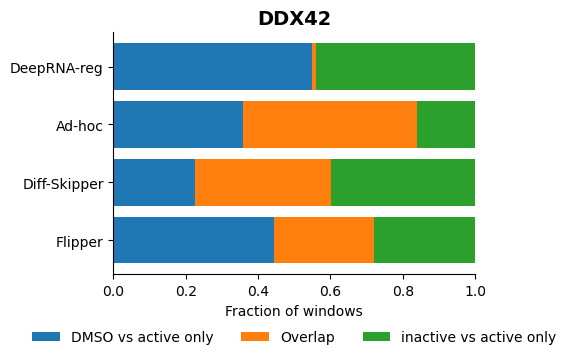

In [15]:
# Extract out the label for each comparison. 
labels = [c[0] for c in comparisons]

# Create empty vectors to store overlap fractions in. 
f_left, f_overlap, f_right = [], [], []
counts = []

# Fill in overlap fractions. 
for _, left_set, right_set in comparisons:
    fl, fo, fr, cts = overlap_fractions(left_set, right_set)
    f_left.append(fl)
    f_overlap.append(fo)
    f_right.append(fr)
    counts.append(cts)

# Specify desired order. 
desired_order = ["DeepRNA-reg", "Ad-hoc", "Diff-Skipper", "Flipper"]

# Build index mapping
order_idx = [labels.index(x) for x in desired_order]

labels = [labels[i] for i in order_idx]
f_left = [f_left[i] for i in order_idx]
f_overlap = [f_overlap[i] for i in order_idx]
f_right = [f_right[i] for i in order_idx]

labels = labels[::-1]
f_left = f_left[::-1]
f_overlap = f_overlap[::-1]
f_right = f_right[::-1]

left_for_overlap = f_left
left_for_right = [l + o for l, o in zip(f_left, f_overlap)]

# Create plot. 
fig, ax = plt.subplots(figsize=(5.5, 3.8))

ax.barh(labels, f_left, label="DMSO vs active only")
ax.barh(labels, f_overlap, left=left_for_overlap, label="Overlap")
ax.barh(labels, f_right, left=left_for_right, label="inactive vs active only")

ax.set_xlim(0, 1)
ax.set_xlabel("Fraction of windows")
ax.set_title("DDX42", fontsize=14, fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)
plt.tight_layout()
plt.savefig("stacked_barplots/DDX42_overlap_bars.svg", bbox_inches="tight")
plt.show()

In [16]:
jaccards = []

for label, left_set, right_set in comparisons:
    inter = len(left_set & right_set)
    union = len(left_set | right_set)
    j = inter / union if union else 0.0
    jaccards.append(j)

for lab, j in zip(labels, jaccards):
    print(f"{lab}\tJaccard={j:.4f}")

Flipper	Jaccard=0.2766
Diff-Skipper	Jaccard=0.0121
Ad-hoc	Jaccard=0.4834
DeepRNA-reg	Jaccard=0.3743
